## Download the dataset and import the packages

In [1]:
!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv

--2026-10-02 12:19:13--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 278746 (272K) [text/plain]
Saving to: ‘course_lead_scoring_2026.csv’

course_lead_scoring 100%[===================>] 272.21K  --.-KB/s    in 0.04s   

2026-10-02 12:19:13 (6.52 MB/s) - ‘course_lead_scoring_2026.csv’ saved [278746/278746]



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Data and exploration

In [3]:
df = pd.read_csv("course_lead_scoring_2026.csv")

In [5]:
df.index

RangeIndex(start=0, stop=5000, step=1)

In [6]:
len(df)

5000

In [7]:
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [8]:
df.dtypes

lead_source                     str
industry                        str
employment_status               str
location                        str
annual_income               float64
number_of_courses_viewed      int64
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [9]:
df.iloc[1000:1005]

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
1000,paid_ads,education,employed,africa,24475.0,4,6,0.56,0
1001,social_media,technology,employed,south_america,71772.0,2,4,0.43,0
1002,events,manufacturing,employed,africa,31153.0,0,4,0.35,0
1003,referral,healthcare,student,north_america,28049.0,2,5,0.60,0
1004,organic_search,finance,unemployed,north_america,61452.0,2,2,0.29,1


In [10]:
df.iloc[1000:2000:100]

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
1000,paid_ads,education,employed,africa,24475.0,4,6,0.56,0
1100,organic_search,technology,self_employed,south_america,72172.0,2,5,0.53,0
1200,paid_ads,technology,student,europe,NaN,2,3,0.39,0
1300,events,technology,employed,asia,81498.0,2,4,0.45,1
1400,organic_search,healthcare,unemployed,asia,29902.0,3,5,0.58,1
1500,organic_search,technology,unemployed,europe,46643.0,3,7,0.65,1
1600,referral,technology,student,asia,48726.0,3,7,0.62,1
1700,paid_ads,healthcare,employed,south_america,61959.0,0,4,0.32,0
1800,referral,healthcare,employed,NaN,57405.0,3,5,0.57,1
1900,paid_ads,education,employed,asia,30355.0,2,6,0.44,0


In [11]:
df.columns

Index(['lead_source', 'industry', 'employment_status', 'location',
       'annual_income', 'number_of_courses_viewed', 'interaction_count',
       'lead_score', 'converted'],
      dtype='str')

## Data preparation


In [12]:
categorical = [s for s in df.columns if df[s].dtypes == "str"]
categorical

['lead_source', 'industry', 'employment_status', 'location']

In [14]:
numerical = [s for s in df.columns if df[s].dtypes == "float64" or df[s].dtypes == "int64"]
numerical.remove("converted")
numerical

['annual_income',
 'number_of_courses_viewed',
 'interaction_count',
 'lead_score']

In [15]:
df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [17]:
for c in categorical:
    df[c] = df[c].fillna("NA")
for c in numerical:
    df[c] = df[c].fillna(0)

In [18]:
df.isnull().sum()

lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [19]:
df.iloc[1000:2000:100]

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
1000,paid_ads,education,employed,africa,24475.0,4,6,0.56,0
1100,organic_search,technology,self_employed,south_america,72172.0,2,5,0.53,0
1200,paid_ads,technology,student,europe,0.0,2,3,0.39,0
1300,events,technology,employed,asia,81498.0,2,4,0.45,1
1400,organic_search,healthcare,unemployed,asia,29902.0,3,5,0.58,1
1500,organic_search,technology,unemployed,europe,46643.0,3,7,0.65,1
1600,referral,technology,student,asia,48726.0,3,7,0.62,1
1700,paid_ads,healthcare,employed,south_america,61959.0,0,4,0.32,0
1800,referral,healthcare,employed,NA,57405.0,3,5,0.57,1
1900,paid_ads,education,employed,asia,30355.0,2,6,0.44,0


In [20]:
from sklearn.model_selection import train_test_split
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

In [21]:
len(df_full_train)

4000

In [22]:
df_test = df_test.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)

y_test = df_test.converted.values
y_val = df_val.converted.values
y_train = df_train.converted.values


In [23]:
del df_test["converted"]
del df_val["converted"]
del df_train["converted"]

## Question 1

In [24]:
from sklearn.metrics import roc_auc_score


In [28]:
for i in numerical:
    auc = roc_auc_score(y_train, df_train[i])
    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[i])
    print(i, auc)


annual_income 0.6081977776250831
number_of_courses_viewed 0.7229894623989618
interaction_count 0.7649203047563227
lead_score 0.7882254810906102


### Answer to question 1: lead_score has the highest AUC

## Question 2

In [30]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [34]:
dv = DictVectorizer(sparse=False)
train_dicts = df_train[categorical + numerical].to_dict(orient="records")
X_train = dv.fit_transform(train_dicts)
model = LogisticRegression(solver="liblinear", C=1.0, max_iter=1000)
model.fit(X_train, y_train)
X_val = dv.transform(df_val[categorical + numerical].to_dict(orient="records"))
y_pred = model.predict_proba(X_val)[:, 1]
round(roc_auc_score(y_val, y_pred), 3)

0.732

### Answer to question 2: 0.732

## Question 3

In [54]:
threshold = np.linspace(0.0,1.0,101)
precision = []
recall = []
for t in threshold:
    y_pred_t = (y_pred >= t).astype(int)
    tp = ((y_val == 1) & (y_pred_t == 1)).sum()
    fp = ((y_val == 0) & (y_pred_t == 1)).sum()
    fn = ((y_val == 1) & (y_pred_t == 0)).sum()
    p = tp / (tp + fp)
    r = tp / (tp + fn)
    precision.append(p)
    recall.append(r)

/tmp/ipykernel_3451/3632256408.py:9: RuntimeWarning: invalid value encountered in scalar divide
  p = tp / (tp + fp)


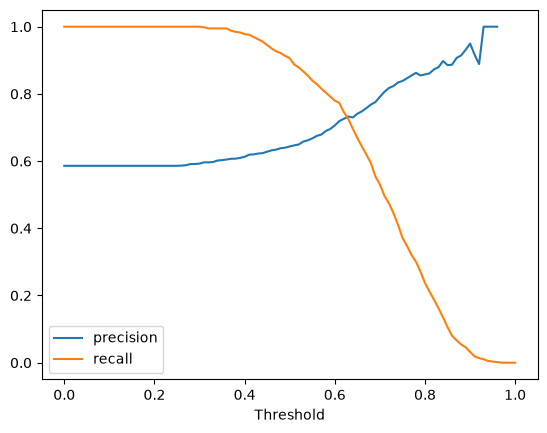

In [55]:
plt.plot(threshold, precision, label="precision")
plt.plot(threshold, recall, label="recall")
plt.xlabel("Threshold")
plt.legend()

In [60]:
diff = np.array(precision) - np.array(recall)
diff[90:100]

array([0.91757679, 0.89789534, 0.87523701, 0.98976109, 0.99488055,
       0.99658703, 0.99829352,        nan,        nan,        nan])

In [57]:
idx = np.argmin(np.abs(diff))
idx

np.int64(97)

In [58]:
diff[96]

np.float64(0.9982935153583617)

In [59]:
idx = np.nanargmin(np.abs(diff))
idx

np.int64(63)

### Answer to question 3: 0.63

## Question 4

In [63]:
F1 = []
for t in threshold:
    y_pred_t = (y_pred >= t).astype(int)
    tp = ((y_val == 1) & (y_pred_t == 1)).sum()
    fp = ((y_val == 0) & (y_pred_t == 1)).sum()
    fn = ((y_val == 1) & (y_pred_t == 0)).sum()
    p = tp / (tp + fp)
    r = tp / (tp + fn)
    F1.append(2 * p * r / (p + r))

/tmp/ipykernel_3451/605207757.py:7: RuntimeWarning: invalid value encountered in scalar divide
  p = tp / (tp + fp)


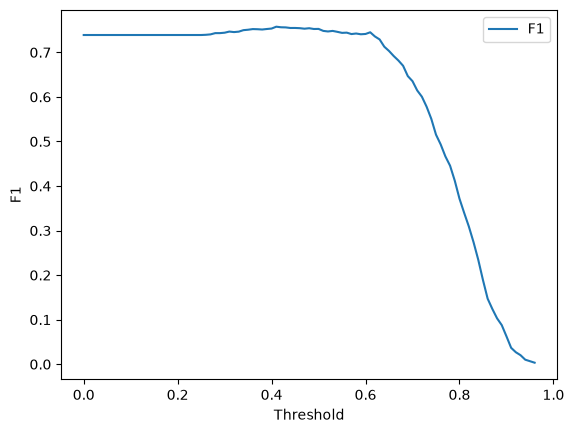

In [64]:
plt.plot(threshold, F1, label="F1")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.legend()
plt.show()

In [65]:
np.nanargmax(F1)

np.int64(41)

### Answer to question 4: 0.41

## Question 5

In [66]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

In [67]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [68]:
from sklearn.model_selection import KFold

In [70]:
n_splits = 5
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values

    dv, model = train(df_train, y_train, C=1.0)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

print(np.std(scores))

0.006853233151022138


### Answer to question 5: 0.007

## Question 6

In [71]:
parameters = [0.000001, 0.001, 1]
for C in parameters:
    scores = []
    n_splits = 5
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print(f"C={C}, mean={np.mean(scores):.3f}, std={np.std(scores):.3f}")

C=1e-06, mean=0.617, std=0.019
C=0.001, mean=0.749, std=0.010
C=1, mean=0.732, std=0.007


### Answer to question 6: 0.001